In [1]:
# a family relational graphRAG to ask queries regarding how people are related

In [2]:
print(9*9)

81


In [17]:
import networkx as nx
import matplotlib.pyplot as plt
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, ToolMessage, SystemMessage
from langchain_core.tools import tool

from pydantic import BaseModel, Field

In [4]:
class Triads(BaseModel):
    list_of_triplets: list[list[str]] = Field(description = "a list of all the relational triplets")

In [22]:

# 1. BUILD THE KNOWLEDGE GRAPH (The "Index")

def get_triads_from_text(input_text:  str) -> list[list[str]]:
    extraction_prompt = f"""
    Extract a Knowledge Graph from the input text below. 
    Rules:
    1. Identify Entities (Nodes) and their Relationships (Edges).
    2. NORMALIZE: Convert all entities to title case (e.g., 'even numbers' -> 'Even Numbers').
    3. OUTPUT: Provide a list of triples in the format: [["Subject", "Relationship", "Object"]].
    4. Remember to only extract DIRECT relationships stated in tehe text. Do not infer other familial 
    titles (like Aunt, uncle, cousin) unless the text explicitly uses those words. Focus on parent/child/siblings only.

    Input Text: {input_text}
    """

    llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
    llm_structured = llm.with_structured_output(Triads)
    response = llm_structured.invoke(input=extraction_prompt)
    triplets = response.list_of_triplets

    return triplets

In [23]:
relation_text = """
Arthur is the patriarch of the Sterling family and is married to Martha. They have two children: a son named Bob and a daughter named Diana. 
Diana eventually married a man named Edward, and together they had a daughter named Alice. Bob, who never married, is known for being the favorite sibling of Diana. 
During the holidays, Alice always looks forward to seeing her mother's brother, as he tells the best stories.
"""
triplets = get_triads_from_text(relation_text)

kg = nx.MultiDiGraph()
for subject, relation, obj in triplets:
    kg.add_edge(subject, obj, relation=relation)

In [24]:
# kg.neighbors("Alice")
triplets

[['Arthur', 'Is Patriarch Of', 'Sterling Family'],
 ['Arthur', 'Is Married To', 'Martha'],
 ['Martha', 'Is Married To', 'Arthur'],
 ['Arthur', 'Is Parent Of', 'Bob'],
 ['Martha', 'Is Parent Of', 'Bob'],
 ['Arthur', 'Is Parent Of', 'Diana'],
 ['Martha', 'Is Parent Of', 'Diana'],
 ['Bob', 'Is Sibling Of', 'Diana'],
 ['Diana', 'Is Sibling Of', 'Bob'],
 ['Diana', 'Is Married To', 'Edward'],
 ['Edward', 'Is Married To', 'Diana'],
 ['Diana', 'Is Parent Of', 'Alice'],
 ['Edward', 'Is Parent Of', 'Alice'],
 ['Bob', 'Is Favorite Sibling Of', 'Diana']]

In [38]:
# 2. DEFINE THE GRAPH TOOL
@tool
def graph_lookup(entity_query: str):
    """Consult the Knowledge Graph to see relationships for a specific entity.
    Look up a SINGLE entity in the knowledge graph to find its relations.
    If you need to lookup multiple entities, make separate tool calls for each entity"""
    
    entity_query = entity_query.title()

    if entity_query not in kg:
        return f"None. {entity_query} not found in graph."
    
    results = []
    for neighbor in kg.neighbors(entity_query):
        edge_data = kg.get_edge_data(entity_query, neighbor)
        relation = edge_data[0]['relation']
        results.append(f"{entity_query} {relation} {neighbor}")
    
    # Look at incoming edges (Who is related to Bob?)
    for u, v, d in kg.in_edges(entity_query, data=True):
        results.append(f"{u} {d['relation']} {entity_query}")
    
    return "\n".join(set(results)) if results else f"No direct relationships found for {entity_query}"


In [64]:
# results = []
# entity_query = "Alice"

# for neighbor in kg.neighbors(entity_query):
#     edge_data = kg.get_edge_data(entity_query, neighbor)
#     relation = edge_data[0]['relation']
#     results.append(f"{entity_query} {relation} {neighbor}")
# print(f"results = {results}")

# for u, v, d in kg.in_edges(entity_query, data=True):
#     print(f"u = {u}, v = {v}, d = {d}")


In [68]:
# 3. THE AGENT LOOP


llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash") # Or your preferred version
llm_with_tools = llm.bind_tools([graph_lookup])

sys_msg = """You are a Genology expert. You MUST use the graph_lookup tool to find the relationships between the individuals. Do not answer from memory. \
To answer relationship questions you MUST:
1. Identify EVERY unique person in the user's question
2. Call graph_lookup tool for every person found
3. Always verify the connections in the Knowledge Graph
4. Explain the connections using only the data returned by the tool
5. If 'Megan' and 'Stella' are mentioned, you must call the tool for 'Megan' AND call it for 'Stella'."""

# query = """Based on the family records, how is Bob related to Alice?"""
query = """Based on the family records, how is Edward related to Martha and Bob?"""

messages = [
    SystemMessage(content=sys_msg),
    HumanMessage(content=query)
]

ai_msg = llm_with_tools.invoke(messages)
print(f"AI Choice: {ai_msg.tool_calls}")

AI Choice: [{'name': 'graph_lookup', 'args': {'entity_query': 'Edward'}, 'id': 'ce1d2e40-16ff-4da5-b87f-2340d8e60f90', 'type': 'tool_call'}, {'name': 'graph_lookup', 'args': {'entity_query': 'Martha'}, 'id': 'f98860af-f596-4565-b7f1-829690f67f32', 'type': 'tool_call'}, {'name': 'graph_lookup', 'args': {'entity_query': 'Bob'}, 'id': '8aa1e982-cb83-4fcf-af28-4d44231e0bf0', 'type': 'tool_call'}]


In [69]:
if ai_msg.tool_calls:
    entities_to_lookup = [tool["args"]["entity_query"]  for tool in ai_msg.tool_calls]
    context_each_entity = [graph_lookup.invoke(entity) for entity in entities_to_lookup]
    context = "\n".join(context_each_entity)
    print(entities_to_lookup)
    print(f"fetched context = {context}")
else:
    context = "The AI didn't identify any entities to look in the graph"

['Edward', 'Martha', 'Bob']
fetched context = Diana Is Married To Edward
Edward Is Married To Diana
Edward Is Parent Of Alice
Martha Is Parent Of Diana
Martha Is Married To Arthur
Martha Is Parent Of Bob
Arthur Is Married To Martha
Diana Is Sibling Of Bob
Bob Is Sibling Of Diana
Arthur Is Parent Of Bob
Martha Is Parent Of Bob


In [70]:
final_response = llm.invoke(f"Context: {context}\n\nQuestion: {query}") 

print("\n--- FINAL ANSWER ---")
print(final_response.content)


--- FINAL ANSWER ---
Based on the family records:

*   Edward is married to Diana.
*   Martha is Diana's mother.
    *   Therefore, Edward is **Martha's son-in-law**.

*   Edward is married to Diana.
*   Diana is Bob's sister.
    *   Therefore, Edward is **Bob's brother-in-law**.


### Visualize the graph

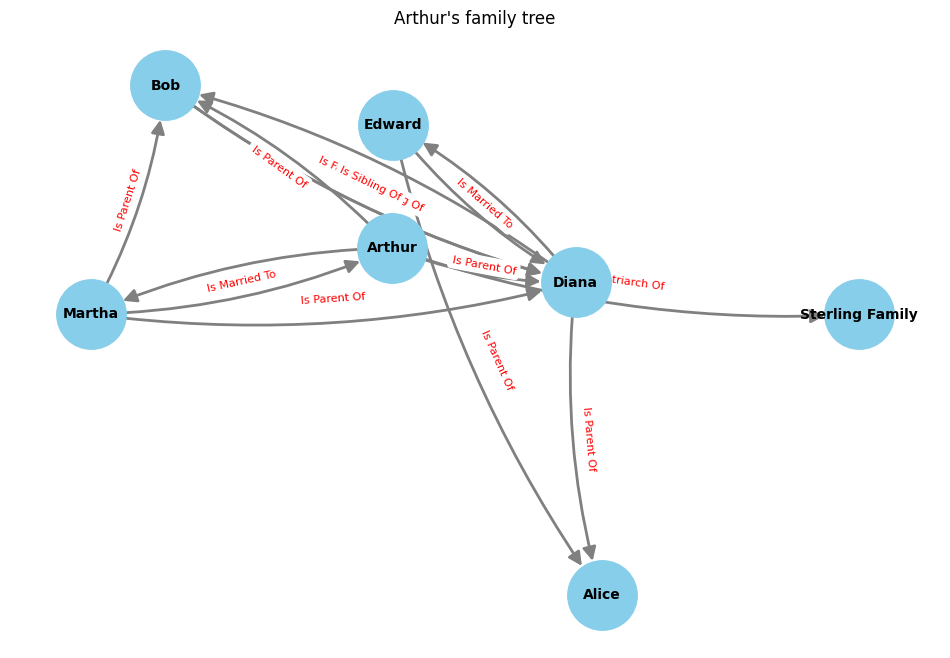

In [45]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_knowledge_graph(graph):
    plt.figure(figsize=(12, 8))
    
    # spring_layout helps spread out nodes so arrows are visible
    pos = nx.spring_layout(graph, k=1.5, seed=42) 
    
    # 1. Draw the Nodes
    nx.draw_networkx_nodes(graph, pos, node_color='skyblue', node_size=2500)
    
    # 2. Draw the Edges with Arrows
    nx.draw_networkx_edges(
        graph, 
        pos, 
        arrowstyle='-|>', 
        arrowsize=20, 
        edge_color='gray',
        width=2,
        node_size=2500, # ADD THIS: Tells the edge where to stop
        connectionstyle='arc3,rad=0.1' # Small radius helps if arrows overlap
    )
    
    # 3. Draw the Node Labels
    nx.draw_networkx_labels(graph, pos, font_size=10, font_weight='bold')
    
    # 4. Draw the Relationship Labels (The "Edges")
    edge_labels = {(u, v): d['relation'] for u, v, d in graph.edges(data=True)}
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_color='red', font_size=8)
    
    plt.title("Arthur's family tree")
    plt.axis('off') # Hide the grid/axis
    plt.show()

# Run the visualization
visualize_knowledge_graph(kg)